<a href="https://colab.research.google.com/github/brittanybee-alt/Supervised-Learning/blob/main/Case_Study_Random_Forest_%5BBrittany_Barrion%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from sklearn.datasets import load_iris
iris = load_iris()

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=10)

model.fit(iris.data, iris.target)

estimator = model.estimators_[5]

from sklearn.tree import export_graphviz

export_graphviz(estimator, out_file='tree.dot',
                feature_names = iris.feature_names,
                class_names = iris.target_names,
                rounded = True, proportion = False,
                precision = 2, filled = True)

from subprocess import call
call(['dot', '-Tpng', 'tree.dot', '-o', 'tree.png', '-Gdpi=600'])

from IPython.display import Image
Image(filename = 'tree.png')

Coronavirus

In [16]:
import os
import pandas as pd
from datetime import datetime,timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import plotly.graph_objects as go
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

In [17]:
url ='/content/PatientInfo.csv'
df = pd.read_csv(url)
df.head()

,patient_id,global_num,sex,birth_year,age,country,province,city,disease,infection_case,infection_order,infected_by,contact_number,symptom_onset_date,confirmed_date,released_date,deceased_date,state
0,1000000001,2.0,male,1964.0,50s,Korea,Seoul,Gangseo-gu,NaN,overseas inflow,1.0,NaN,75.0,2020-01-22,2020-01-23,2020-02-05,NaN,released
1,1000000002,5.0,male,1987.0,30s,Korea,Seoul,Jungnang-gu,NaN,overseas inflow,1.0,NaN,31.0,NaN,2020-01-30,2020-03-02,NaN,released
2,1000000003,6.0,male,1964.0,50s,Korea,Seoul,Jongno-gu,NaN,contact with patient,2.0,2.002000e+09,17.0,NaN,2020-01-30,2020-02-19,NaN,released
3,1000000004,7.0,male,1991.0,20s,Korea,Seoul,Mapo-gu,NaN,overseas inflow,1.0,NaN,9.0,2020-01-26,2020-01-30,2020-02-15,NaN,released
4,1000000005,9.0,female,1992.0,20s,Korea,Seoul,Seongbuk-gu,NaN,contact with patient,2.0,1.000000e+09,2.0,NaN,2020-01-31,2020-02-24,NaN,released


In [18]:
df.shape

(2218, 18)

In [19]:
na_df=pd.DataFrame(df.isnull().sum().sort_values(ascending=False)).reset_index()
na_df.columns = ['VarName', 'NullCount']
na_df[(na_df['NullCount']>0)]

,VarName,NullCount
0,disease,2199
1,deceased_date,2186
2,infection_order,2176
3,symptom_onset_date,2025
4,released_date,1995
5,contact_number,1807
6,infected_by,1749
7,infection_case,1055
8,global_num,904
9,birth_year,454


In [20]:
df.state.value_counts()

,count
state,
isolated,1791
released,307
deceased,32


In [21]:
df['n_age'] = 2026 - df['birth_year']

In [22]:
df.columns

Index(['patient_id', 'global_num', 'sex', 'birth_year', 'age', 'country',
       'province', 'city', 'disease', 'infection_case', 'infection_order',
       'infected_by', 'contact_number', 'symptom_onset_date', 'confirmed_date',
       'released_date', 'deceased_date', 'state', 'n_age'],
      dtype='object')

Handle Missing Values

In [23]:
missing = df.isnull().sum()
print(missing)

patient_id               0
global_num             904
sex                    145
birth_year             454
age                    261
country                  0
province                 0
city                    65
disease               2199
infection_case        1055
infection_order       2176
infected_by           1749
contact_number        1807
symptom_onset_date    2025
confirmed_date         141
released_date         1995
deceased_date         2186
state                   88
n_age                  454
dtype: int64


In [24]:
df['disease'].value_counts(dropna=False)

,count
disease,
NaN,2199
True,19


In [25]:
df['disease'] = df['disease'].fillna(0).astype(int)

In [26]:
df['disease'].value_counts(dropna=False)

,count
disease,
0,2199
1,19


In [27]:
cols = ['global_num', 'birth_year', 'infection_order', 'infected_by', 'contact_number']

df[cols] = df[cols].fillna(df[cols].mean())

In [30]:
df['n_age'] = 2026 - df['birth_year']

cat_cols = ['sex', 'age', 'country', 'province', 'city', 'infection_case']
cat_cols = [c for c in cat_cols if c in df.columns]
df[cat_cols] = df[cat_cols].fillna('Unknown')

date_cols = ['symptom_onset_date', 'confirmed_date', 'released_date', 'deceased_date']
for c in date_cols:
    if c in df.columns:
        df[c + '_missing'] = df[c].isnull().astype(int)
        df[c] = df[c].fillna('Unknown')

num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(df.isnull().sum())

patient_id                     0
global_num                     0
sex                            0
birth_year                     0
age                            0
country                        0
province                       0
city                           0
disease                        0
infection_case                 0
infection_order                0
infected_by                    0
contact_number                 0
symptom_onset_date             0
confirmed_date                 0
released_date                  0
deceased_date                  0
state                         88
n_age                          0
symptom_onset_date_missing     0
confirmed_date_missing         0
released_date_missing          0
deceased_date_missing          0
dtype: int64


In [31]:
df['state'] = df['state'].fillna('Unknown')

In [32]:
print(df.isnull().sum())

patient_id                    0
global_num                    0
sex                           0
birth_year                    0
age                           0
country                       0
province                      0
city                          0
disease                       0
infection_case                0
infection_order               0
infected_by                   0
contact_number                0
symptom_onset_date            0
confirmed_date                0
released_date                 0
deceased_date                 0
state                         0
n_age                         0
symptom_onset_date_missing    0
confirmed_date_missing        0
released_date_missing         0
deceased_date_missing         0
dtype: int64


In [34]:
df.head()

,patient_id,global_num,sex,birth_year,age,country,province,city,disease,infection_case,...,symptom_onset_date,confirmed_date,released_date,deceased_date,state,n_age,symptom_onset_date_missing,confirmed_date_missing,released_date_missing,deceased_date_missing
0,1000000001,2.0,male,1964.0,50s,Korea,Seoul,Gangseo-gu,0,overseas inflow,...,2020-01-22,2020-01-23,2020-02-05,Unknown,released,62.0,0,0,0,1
1,1000000002,5.0,male,1987.0,30s,Korea,Seoul,Jungnang-gu,0,overseas inflow,...,Unknown,2020-01-30,2020-03-02,Unknown,released,39.0,1,0,0,1
2,1000000003,6.0,male,1964.0,50s,Korea,Seoul,Jongno-gu,0,contact with patient,...,Unknown,2020-01-30,2020-02-19,Unknown,released,62.0,1,0,0,1
3,1000000004,7.0,male,1991.0,20s,Korea,Seoul,Mapo-gu,0,overseas inflow,...,2020-01-26,2020-01-30,2020-02-15,Unknown,released,35.0,0,0,0,1
4,1000000005,9.0,female,1992.0,20s,Korea,Seoul,Seongbuk-gu,0,contact with patient,...,Unknown,2020-01-31,2020-02-24,Unknown,released,34.0,1,0,0,1


In [35]:
df = df.drop(['symptom_onset_date','confirmed_date','released_date','deceased_date'],axis =1)

In [36]:
print(df.nunique())

patient_id                    2218
global_num                    1304
sex                              3
birth_year                      97
age                             12
country                          4
province                        17
city                           135
disease                          2
infection_case                  17
infection_order                  7
infected_by                    207
contact_number                  73
state                            4
n_age                           97
symptom_onset_date_missing       2
confirmed_date_missing           2
released_date_missing            2
deceased_date_missing            2
dtype: int64


In [37]:
print(df.nunique()/df.shape[0])

patient_id                    1.000000
global_num                    0.587917
sex                           0.001353
birth_year                    0.043733
age                           0.005410
country                       0.001803
province                      0.007665
city                          0.060866
disease                       0.000902
infection_case                0.007665
infection_order               0.003156
infected_by                   0.093327
contact_number                0.032913
state                         0.001803
n_age                         0.043733
symptom_onset_date_missing    0.000902
confirmed_date_missing        0.000902
released_date_missing         0.000902
deceased_date_missing         0.000902
dtype: float64


In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,2218.0,4.014678e+09,2.192419e+09,1.000000e+09,1.700000e+09,6.001000e+09,6.004000e+09,7.000000e+09
global_num,2218.0,4.664817e+03,2.211785e+03,1.000000e+00,4.205250e+03,4.664817e+03,5.900250e+03,8.717000e+03
birth_year,2218.0,1.974989e+03,1.731123e+01,1.916000e+03,1.965000e+03,1.974989e+03,1.988000e+03,2.020000e+03
disease,2218.0,8.566276e-03,9.217769e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
infection_order,2218.0,2.285714e+00,1.706622e-01,1.000000e+00,2.285714e+00,2.285714e+00,2.285714e+00,6.000000e+00
infected_by,2218.0,2.600789e+09,7.216328e+08,1.000000e+09,2.600789e+09,2.600789e+09,2.600789e+09,6.113000e+09
contact_number,2218.0,2.412895e+01,3.917141e+01,0.000000e+00,2.412895e+01,2.412895e+01,2.412895e+01,1.160000e+03
n_age,2218.0,5.101134e+01,1.731123e+01,6.000000e+00,3.800000e+01,5.101134e+01,6.100000e+01,1.100000e+02
symptom_onset_date_missing,2218.0,9.129847e-01,2.819211e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
confirmed_date_missing,2218.0,6.357078e-02,2.440418e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [39]:
duplicateRowsDF = df[df.duplicated()]
duplicateRowsDF

,patient_id,global_num,sex,birth_year,age,country,province,city,disease,infection_case,infection_order,infected_by,contact_number,state,n_age,symptom_onset_date_missing,confirmed_date_missing,released_date_missing,deceased_date_missing


In [40]:
dfo = df.select_dtypes(include=['object'], exclude=['datetime'])
dfo.shape
#get levels for all variables
vn = pd.DataFrame(dfo.nunique()).reset_index()
vn.columns = ['VarName', 'LevelsCount']
vn.sort_values(by='LevelsCount', ascending =False)
vn

,VarName,LevelsCount
0,sex,3
1,age,12
2,country,4
3,province,17
4,city,135
5,infection_case,17
6,state,4


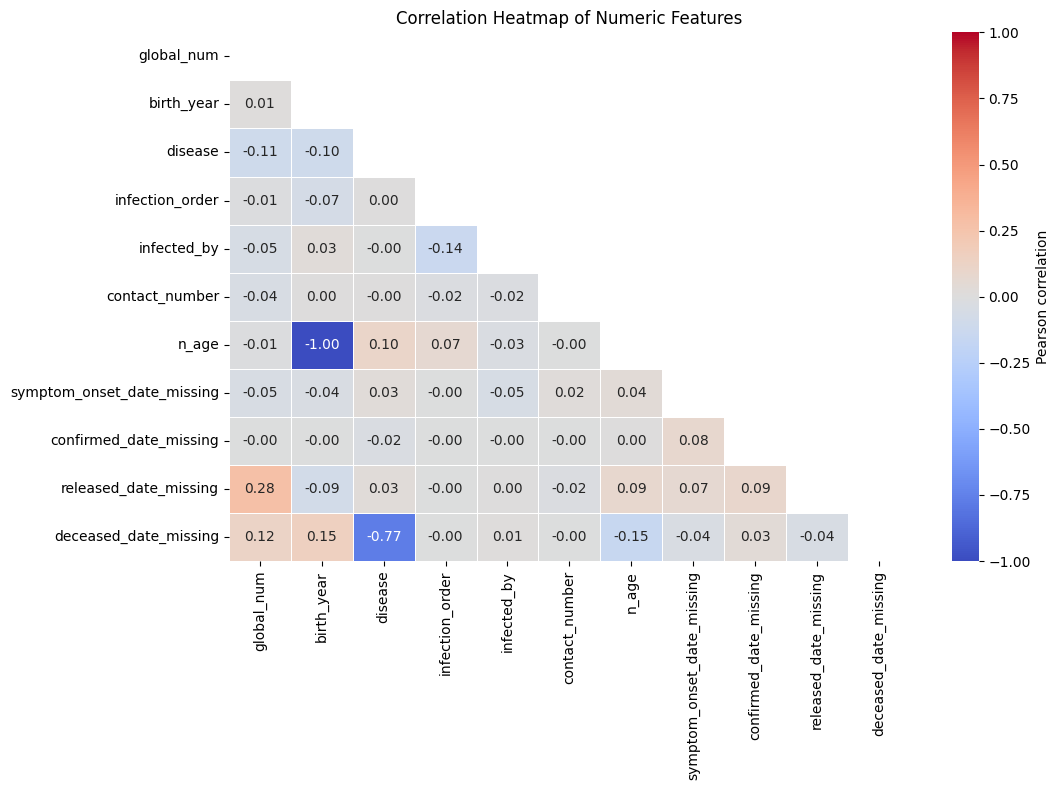

In [41]:
# Numeric features only; patient_id is just an identifier, so leave it out
corr_df = df.select_dtypes(include='number').drop(columns=['patient_id'], errors='ignore')
corr = corr_df.corr()

# Mask the upper triangle so each pair appears once
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=0.5,
            cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

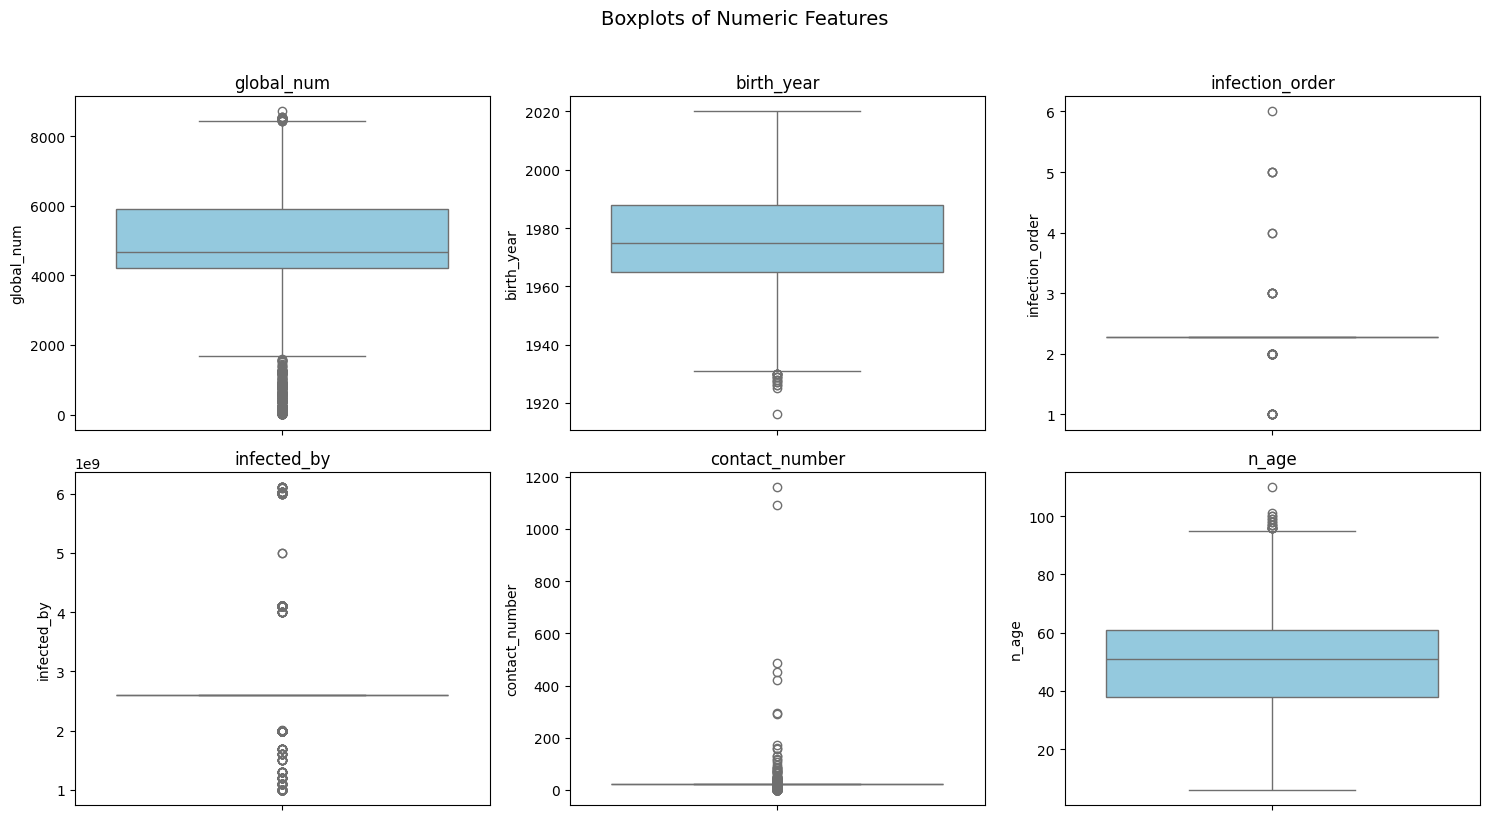

In [42]:
# Continuous numeric features only: skip the ID, the 0/1 flags, and the binary disease column
num_df = df.select_dtypes(include='number').drop(columns=['patient_id'], errors='ignore')
num_df = num_df.drop(columns=[c for c in num_df if c.endswith('_missing')] + ['disease'], errors='ignore')

n_cols = 3
n_rows = int(np.ceil(len(num_df.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).flatten()

for ax, col in zip(axes, num_df.columns):
    sns.boxplot(y=num_df[col], ax=ax, color='skyblue')
    ax.set_title(col)

# Hide any unused subplot slots
for ax in axes[len(num_df.columns):]:
    ax.set_visible(False)

plt.suptitle('Boxplots of Numeric Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
# Check the levels per object column first (high-cardinality columns create many dummies)
obj_cols = df.select_dtypes(include='object').columns.tolist()
print(df[obj_cols].nunique().sort_values(ascending=False))

city              135
province           17
infection_case     17
age                12
country             4
state               4
sex                 3
dtype: int64


In [44]:
df_dummies = pd.get_dummies(df, columns=obj_cols, drop_first=True, dtype=int)

print(df_dummies.shape)
df_dummies.head()

(2218, 197)


,patient_id,global_num,birth_year,disease,infection_order,infected_by,contact_number,n_age,symptom_onset_date_missing,confirmed_date_missing,...,infection_case_Suyeong-gu Kindergarten,infection_case_Unknown,infection_case_contact with patient,infection_case_etc,infection_case_gym facility in Cheonan,infection_case_gym facility in Sejong,infection_case_overseas inflow,state_deceased,state_isolated,state_released
0,1000000001,2.0,1964.0,0,1.0,2.600789e+09,75.0,62.0,0,0,...,0,0,0,0,0,0,1,0,0,1
1,1000000002,5.0,1987.0,0,1.0,2.600789e+09,31.0,39.0,1,0,...,0,0,0,0,0,0,1,0,0,1
2,1000000003,6.0,1964.0,0,2.0,2.002000e+09,17.0,62.0,1,0,...,0,0,1,0,0,0,0,0,0,1
3,1000000004,7.0,1991.0,0,1.0,2.600789e+09,9.0,35.0,0,0,...,0,0,0,0,0,0,1,0,0,1
4,1000000005,9.0,1992.0,0,2.0,1.000000e+09,2.0,34.0,1,0,...,0,0,1,0,0,0,0,0,0,1


In [45]:
def group_rare(series, min_count=50):
    counts = series.value_counts()
    rare = counts[counts < min_count].index
    return series.where(~series.isin(rare), 'Other')

df_model = df.copy()
for c in ['city', 'infection_case']:
    if c in df_model.columns:
        df_model[c] = group_rare(df_model[c], min_count=50)

df_dummies = pd.get_dummies(df_model, columns=obj_cols, drop_first=True, dtype=int)
print(df_dummies.shape)

(2218, 59)


In [47]:
from sklearn.model_selection import train_test_split

# Define target y and features X
# Using 'state_released' as an example target, and dropping other state outcomes and patient_id
y = df_dummies['state_released']
X = df_dummies.drop(columns=['patient_id', 'state_deceased', 'state_isolated', 'state_released'], errors='ignore')

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1774, 55)
X_test shape: (444, 55)


In [48]:
#scale data
from sklearn import preprocessing
import numpy as np
# build scaler based on training data and apply it to test data to then also scale the test data
scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [49]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,roc_auc_score
from sklearn.metrics import accuracy_score,log_loss
from matplotlib import pyplot

Fit Random Forest Classifier

In [50]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=300, random_state = 1,n_jobs=-1)
model_res = clf.fit(X_train_scaled, y_train)
y_pred = model_res.predict(X_test_scaled)
y_pred_prob = model_res.predict_proba(X_test_scaled)
lr_probs = y_pred_prob[:,1]
ac = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print('Random Forest: Accuracy=%.3f' % (ac))

print('Random Forest: f1-score=%.3f' % (f1))

Random Forest: Accuracy=0.966
Random Forest: f1-score=0.965


Create Confusion Matrix Plots

In [51]:
class_names=['isolated','released','missing','deceased']

Confusion matrix, without normalization
[[374   1]
 [ 14  55]]
Normalized confusion matrix
[[1.  0. ]
 [0.2 0.8]]


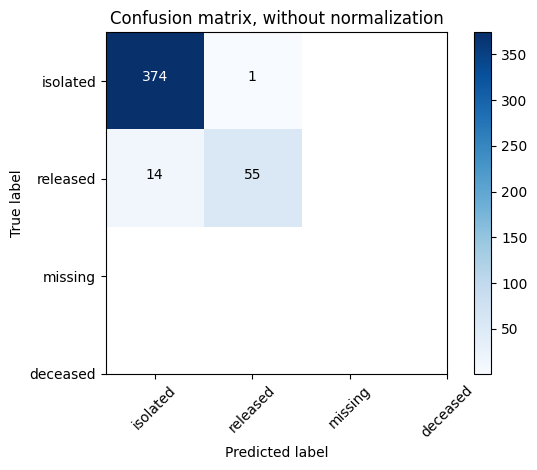

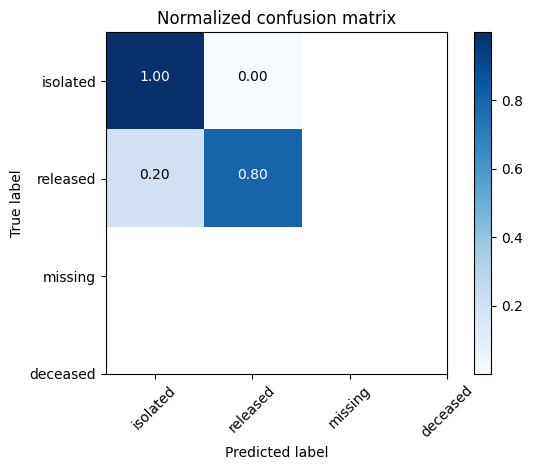

In [52]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names,
                      title='Confusion matrix, without normalization')
#plt.savefig('figures/RF_cm_multi_class.png')

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Normalized confusion matrix')
#plt.savefig('figures/RF_cm_proportion_multi_class.png', bbox_inches="tight")
plt.show()

Plot feature importances

30


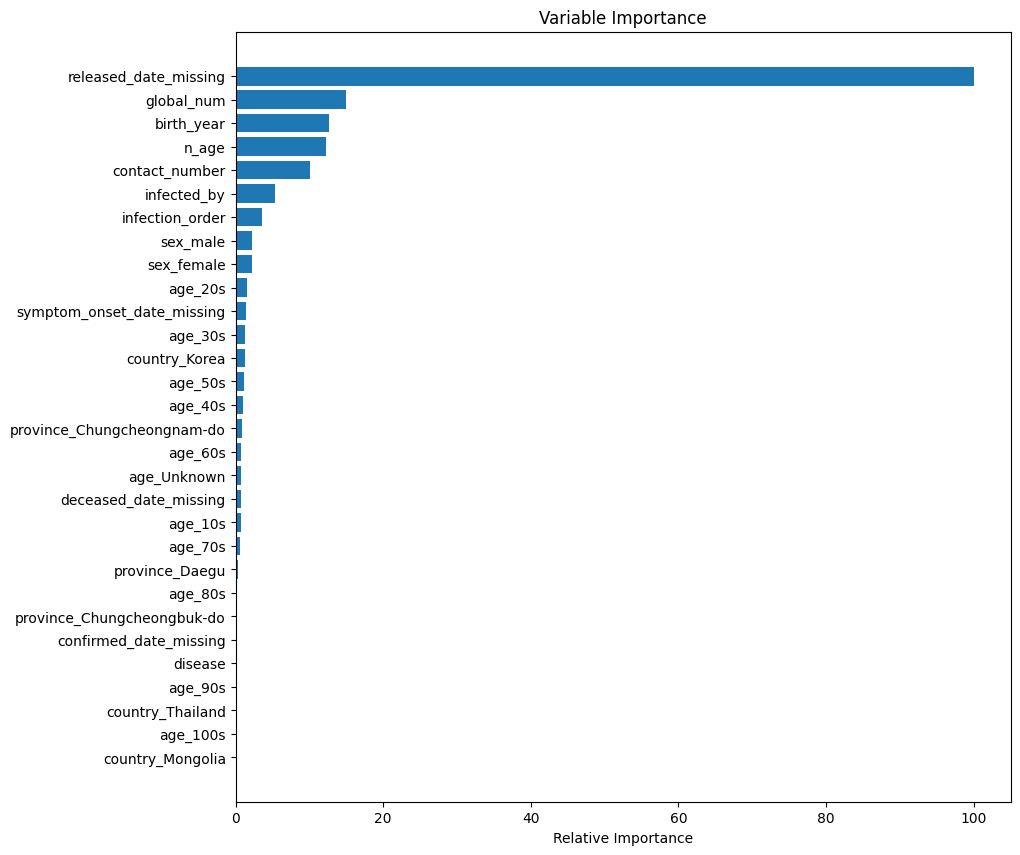

In [53]:
feature_importance = clf.feature_importances_
# make importances relative to max importance
feature_importance = 100.0 * (feature_importance / feature_importance.max())[:30]
sorted_idx = np.argsort(feature_importance)[:30]

pos = np.arange(sorted_idx.shape[0]) + .5
print(pos.size)
sorted_idx.size
plt.figure(figsize=(10,10))
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, X.columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.title('Variable Importance')
plt.show()